## 5 - Modeling MVP

Datasets:
- **Base**: `datasets/model_ready_crime_nbh_2024.csv`
- **Spatial**: `datasets/spatial_dataset_crime_nbh_2024.csv`

Models:
1. OLS linear regression
2. Random Forest regressor
3. XGBoost regressor


## 2. Imports and reproducibility settings


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [2]:
# XGBoost import (macOS fix: ensure OpenMP runtime is discoverable)
# If you installed libomp via Homebrew into /usr/local (Intel Homebrew), the dynamic loader
# might not search that path by default for wheels that expect /opt/homebrew.
import os

_libomp_candidates = [
    "/usr/local/opt/libomp/lib",
    "/opt/homebrew/opt/libomp/lib",
]

for p in _libomp_candidates:
    if os.path.isdir(p):
        os.environ["DYLD_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_LIBRARY_PATH", "")
        os.environ["DYLD_FALLBACK_LIBRARY_PATH"] = p + ":" + os.environ.get("DYLD_FALLBACK_LIBRARY_PATH", "")

try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except Exception as e:
    XGBOOST_AVAILABLE = False
    XGBOOST_IMPORT_ERROR = repr(e)

print("XGBoost available:", XGBOOST_AVAILABLE)
if not XGBOOST_AVAILABLE:
    print("XGBoost import error:", XGBOOST_IMPORT_ERROR)
    print("\nIf this is a libomp error on macOS, run:")
    print("- `brew install libomp`")
    print("Then restart the kernel (Kernel → Restart) and rerun.")


XGBoost available: True


In [3]:
# Package versions (reproducibility)
try:
    from importlib.metadata import version
except Exception:
    from importlib_metadata import version  # type: ignore

pkgs = ["numpy", "pandas", "matplotlib", "seaborn", "scikit-learn", "xgboost"]
versions = {}
for p in pkgs:
    try:
        versions[p] = version(p)
    except Exception:
        versions[p] = None
print(json.dumps(versions, indent=2))


{
  "numpy": "1.26.4",
  "pandas": "2.3.3",
  "matplotlib": "3.10.8",
  "seaborn": "0.13.2",
  "scikit-learn": "1.8.0",
  "xgboost": "3.2.0"
}


## 3. Load datasets


In [4]:
DATA_DIR = Path("datasets")
OUT_DIR = Path("outputs") / "modeling_mvp"
OUT_DIR.mkdir(parents=True, exist_ok=True)

BASE_PATH = DATA_DIR / "model_ready_crime_nbh_2024.csv"
SPATIAL_PATH = DATA_DIR / "spatial_dataset_crime_nbh_2024.csv"

base_df = pd.read_csv(BASE_PATH)
spatial_df = pd.read_csv(SPATIAL_PATH)

print("base_df shape:", base_df.shape)
print("spatial_df shape:", spatial_df.shape)
print("\nbase_df first 10 columns:", base_df.columns[:10].tolist())
print("spatial_df first 10 columns:", spatial_df.columns[:10].tolist())

if base_df.shape[1] <= 200:
    print("\nbase_df columns:")
    print(base_df.columns.tolist())
if spatial_df.shape[1] <= 250:
    print("\nspatial_df columns:")
    print(spatial_df.columns.tolist())


base_df shape: (14019, 106)
spatial_df shape: (14019, 116)

base_df first 10 columns: ['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw']
spatial_df first 10 columns: ['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw']

base_df columns:
['gwb_code_10', 'gwb_code_8', 'regio', 'gm_naam', 'recs', 'gwb_code', 'ind_wbi', 'a_inw', 'a_man', 'a_vrouw', 'a_00_14', 'a_15_24', 'a_25_44', 'a_45_64', 'a_65_oo', 'a_ongeh', 'a_gehuwd', 'a_gesch', 'a_verwed', 'a_nl_all', 'a_eur_al', 'a_neu_al', 'a_geb_nl', 'a_geb_eu', 'a_geb_ne', 'a_gbl_eu', 'a_gbl_ne', 'a_geb', 'p_geb', 'a_ste', 'p_ste', 'a_hh', 'a_1p_hh', 'a_hh_z_k', 'a_hh_m_k', 'g_hhgro', 'bev_dich', 'a_woning', 'a_nb_won ', 'a_vastg', 'a_nb_vastg', 'g_wozbag', 'p_1gezw', 'p_1gezw_tw', 'p_1gezw_hw', 'p_1gezw_2w', 'p_1gezw_hvw', 'p_mgezw', 'p_leegsw', 'p_koopw', 'p_huurw', 'p_wcorpw', 'p_ov_hw', 'p_bj_me10', 'p_bj_mi10', 'g_ele', 'g_el

/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_36558/2305271696.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  base_df = pd.read_csv(BASE_PATH)
/var/folders/1l/q5ftm2z17hx00h6p9y5vjql80000gn/T/ipykernel_36558/2305271696.py:9: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  spatial_df = pd.read_csv(SPATIAL_PATH)


## 4. Inspect columns and select target / ID / grouping variables


Chosen common target: log_crime_count
Group column (preferred GroupKFold): gm_naam
Detected ID-like columns (base): ['gwb_code_10', 'gwb_code_8', 'regio', 'gwb_code', 'ID', 'centroid_x', 'centroid_y']
Detected ID-like columns (spatial): ['gwb_code_10', 'gwb_code_8', 'regio', 'gwb_code', 'ID', 'centroid_x', 'centroid_y']

Target descriptive statistics:
count    14019.000000
mean         3.135936
std          1.376612
min          0.000000
25%          2.197225
50%          3.178054
75%          4.077537
max          8.220134


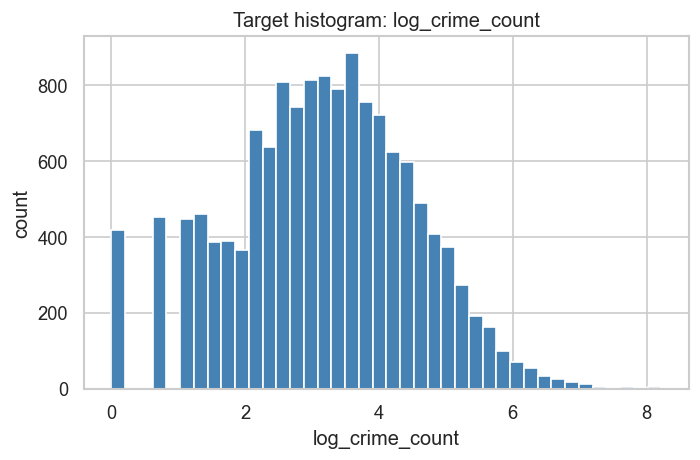


Note: target is already transformed by preprocessing (log1p).


In [5]:
TARGET_PREFERENCE = [
    "log_crime_rate",
    "y_log_crime_rate_per_1k",
    "log_crime_count",
    "y_log_crime_count",
]

RAW_TARGET_LIKE = {
    "crime_count",
    "crime_rate_per_1000",
    "population",
    "population_zero",
    "GeregistreerdeMisdrijven_1",
    "a_inw",
}

ID_COL_HINTS = ["gwb_code", "buurt", "wijk", "code", "id", "regio"]
GROUP_COL_CANDIDATES = ["gm_naam", "gm_code", "gemeente", "municipality", "municipality_code"]

EQUIVALENT_TARGETS = {
    # Treat these as equivalent scales
    "log_crime_rate": ["y_log_crime_rate_per_1k"],
    "log_crime_count": ["y_log_crime_count"],
}


def harmonize_targets(base: pd.DataFrame, spatial: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Create missing preferred target columns by aliasing equivalent ones.

    This keeps the notebook runnable even if preprocessing used different naming.
    """
    base = base.copy()
    spatial = spatial.copy()

    for preferred, equivs in EQUIVALENT_TARGETS.items():
        # If preferred missing in base, but an equivalent exists, alias it.
        if preferred not in base.columns:
            for e in equivs:
                if e in base.columns:
                    base[preferred] = base[e]
                    break
        if preferred not in spatial.columns:
            for e in equivs:
                if e in spatial.columns:
                    spatial[preferred] = spatial[e]
                    break

    return base, spatial


def choose_common_target(base: pd.DataFrame, spatial: pd.DataFrame) -> str:
    """Pick one target column that exists in BOTH datasets, using preference order."""
    for t in TARGET_PREFERENCE:
        if t in base.columns and t in spatial.columns:
            return t

    base_has = [t for t in TARGET_PREFERENCE if t in base.columns]
    spatial_has = [t for t in TARGET_PREFERENCE if t in spatial.columns]

    raise ValueError(
        "No common preferred target found across base and spatial datasets after harmonization.\n"
        f"Base has: {base_has}\n"
        f"Spatial has: {spatial_has}\n"
        "Fix by aligning preprocessing exports or adjust TARGET_PREFERENCE."
    )

def detect_group_col(df: pd.DataFrame) -> Optional[str]:
    for c in GROUP_COL_CANDIDATES:
        if c in df.columns:
            return c
    return None

def detect_id_cols(df: pd.DataFrame) -> List[str]:
    out: List[str] = []
    for c in df.columns:
        cl = c.lower()
        if any(h in cl for h in ID_COL_HINTS):
            out.append(c)
    for c in ["gwb_code_10", "buurtcode", "ID"]:
        if c in df.columns and c not in out:
            out.append(c)
    return out

base_df, spatial_df = harmonize_targets(base_df, spatial_df)
TARGET_COL = choose_common_target(base_df, spatial_df)
print("Chosen common target:", TARGET_COL)

GROUP_COL = detect_group_col(base_df) or detect_group_col(spatial_df)
print("Group column (preferred GroupKFold):", GROUP_COL)

ID_COLS_BASE = detect_id_cols(base_df)
ID_COLS_SPATIAL = detect_id_cols(spatial_df)
print("Detected ID-like columns (base):", ID_COLS_BASE)
print("Detected ID-like columns (spatial):", ID_COLS_SPATIAL)

print("\nTarget descriptive statistics:")
print(base_df[TARGET_COL].describe().to_string())

plt.figure(figsize=(6, 4))
plt.hist(base_df[TARGET_COL].dropna(), bins=40, color="steelblue", edgecolor="white")
plt.title(f"Target histogram: {TARGET_COL}")
plt.xlabel(TARGET_COL)
plt.ylabel("count")
plt.tight_layout()
plt.savefig(OUT_DIR / f"target_hist_{TARGET_COL}.png")
plt.show()

print("\nNote: target is already transformed by preprocessing (log1p).")


## 5. Define feature matrices


In [6]:
LAG_LEAKAGE_REGEX = re.compile(r"lag_.*crime|crime.*lag|spillover_lag", flags=re.IGNORECASE)

def leakage_cols(df: pd.DataFrame) -> List[str]:
    return [c for c in df.columns if LAG_LEAKAGE_REGEX.search(c)]

def geometry_like_cols(df: pd.DataFrame) -> List[str]:
    out: List[str] = []
    for c in df.columns:
        cl = c.lower()
        if "geometry" in cl or cl.endswith("_wkt") or cl in {"centroid", "geom"}:
            out.append(c)
    return out

def select_numeric_features(df: pd.DataFrame, target: str, id_cols: Iterable[str]) -> Tuple[pd.DataFrame, pd.Series, Dict[str, Any]]:
    id_cols = [c for c in id_cols if c in df.columns]
    leak = leakage_cols(df)
    geom = geometry_like_cols(df)

    exclude = set(id_cols) | set(geom) | set(leak)
    exclude.add(target)
    exclude |= RAW_TARGET_LIKE
    exclude |= set(TARGET_PREFERENCE)

    num_cols = df.select_dtypes(include=["number"]).columns.tolist()
    feature_cols = [c for c in num_cols if c not in exclude]

    X = df[feature_cols].copy()
    y = df[target].copy()

    return X, y, {
        "n_features": len(feature_cols),
        "leakage_cols": leak,
        "geometry_cols": geom,
        "feature_cols": feature_cols,
    }

X_base, y_base, info_base = select_numeric_features(base_df, TARGET_COL, ID_COLS_BASE)
X_spatial, y_spatial, info_spatial = select_numeric_features(spatial_df, TARGET_COL, ID_COLS_SPATIAL)

print("Base predictors:", info_base["n_features"])
print("Spatial predictors:", info_spatial["n_features"])

spillover_cols = [c for c in X_spatial.columns if c.startswith("queen_lag_")]
print("\nSpillover columns present (spatial):", len(spillover_cols))
print(spillover_cols[:50])

print("\nPotential leakage cols (base):", info_base["leakage_cols"])
print("Potential leakage cols (spatial):", info_spatial["leakage_cols"])


Base predictors: 84
Spatial predictors: 94

Spillover columns present (spatial): 10
['queen_lag_sum_pop_density_per_km2', 'queen_lag_mean_pop_density_per_km2', 'queen_lag_sum_ste_oad', 'queen_lag_mean_ste_oad', 'queen_lag_sum_p_huurw', 'queen_lag_mean_p_huurw', 'queen_lag_sum_g_pau_km', 'queen_lag_mean_g_pau_km', 'queen_lag_sum_g_pau_hh', 'queen_lag_mean_g_pau_hh']

Potential leakage cols (base): []
Potential leakage cols (spatial): []


## 6. Define leakage-safe pipelines


In [7]:
def make_ols_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])


def make_rf_pipeline() -> Pipeline:
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


def make_xgb_pipeline() -> Pipeline:
    if not XGBOOST_AVAILABLE:
        raise ImportError(
            "xgboost is not available. Install it and rerun. "
            f"Import error was: {XGBOOST_IMPORT_ERROR}"
        )
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", xgb.XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])


## 7. Cross-validation strategy


In [8]:
def make_cv(groups: Optional[pd.Series]) -> Tuple[Any, str]:
    if groups is not None:
        return GroupKFold(n_splits=5), f"GroupKFold(n_splits=5) on '{groups.name}'"
    return KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE), "KFold(n_splits=5, shuffle=True, random_state=42)"


def print_fold_diagnostics(cv, X: pd.DataFrame, y: pd.Series, groups: Optional[pd.Series]):
    print("Fold diagnostics:")
    for i, (tr, va) in enumerate(cv.split(X, y, groups)):
        print(f"- fold {i}: train={len(tr):,}, val={len(va):,}")
        if groups is not None:
            gtr = set(groups.iloc[tr].astype(str))
            gva = set(groups.iloc[va].astype(str))
            overlap = gtr.intersection(gva)
            print(f"  group overlap: {len(overlap)}")
            if overlap:
                raise ValueError("Group overlap detected between train and validation folds")


groups_base = base_df[GROUP_COL] if GROUP_COL and GROUP_COL in base_df.columns else None
groups_spatial = spatial_df[GROUP_COL] if GROUP_COL and GROUP_COL in spatial_df.columns else None

cv_base, cv_base_desc = make_cv(groups_base)
cv_spatial, cv_spatial_desc = make_cv(groups_spatial)

print("Base CV strategy:", cv_base_desc)
print_fold_diagnostics(cv_base, X_base, y_base, groups_base)

print("\nSpatial CV strategy:", cv_spatial_desc)
print_fold_diagnostics(cv_spatial, X_spatial, y_spatial, groups_spatial)


Base CV strategy: GroupKFold(n_splits=5) on 'gm_naam'
Fold diagnostics:
- fold 0: train=11,215, val=2,804
  group overlap: 0
- fold 1: train=11,215, val=2,804
  group overlap: 0
- fold 2: train=11,215, val=2,804
  group overlap: 0
- fold 3: train=11,215, val=2,804
  group overlap: 0
- fold 4: train=11,216, val=2,803
  group overlap: 0

Spatial CV strategy: GroupKFold(n_splits=5) on 'gm_naam'
Fold diagnostics:
- fold 0: train=11,215, val=2,804
  group overlap: 0
- fold 1: train=11,215, val=2,804
  group overlap: 0
- fold 2: train=11,215, val=2,804
  group overlap: 0
- fold 3: train=11,215, val=2,804
  group overlap: 0
- fold 4: train=11,216, val=2,803
  group overlap: 0


## Helper functions for evaluation


In [9]:
def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def evaluate_cv_oof(
    model: Pipeline,
    X: pd.DataFrame,
    y: pd.Series,
    cv,
    groups: Optional[pd.Series],
    model_name: str,
    dataset_name: str,
    id_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    oof_pred = np.full(len(y), np.nan, dtype=float)
    fold_rows = []

    for fold, (tr, va) in enumerate(cv.split(X, y, groups)):
        X_tr, y_tr = X.iloc[tr], y.iloc[tr]
        X_va, y_va = X.iloc[va], y.iloc[va]

        model_fold = Pipeline(steps=model.steps)
        model_fold.fit(X_tr, y_tr)

        pred_tr = model_fold.predict(X_tr)
        pred_va = model_fold.predict(X_va)

        oof_pred[va] = pred_va

        fold_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "fold": fold,
            "n_train": len(tr),
            "n_val": len(va),
            "rmse_train": rmse(y_tr, pred_tr),
            "rmse_val": rmse(y_va, pred_va),
            "mae_train": float(mean_absolute_error(y_tr, pred_tr)),
            "mae_val": float(mean_absolute_error(y_va, pred_va)),
            "r2_train": float(r2_score(y_tr, pred_tr)),
            "r2_val": float(r2_score(y_va, pred_va)),
        })

    fold_df = pd.DataFrame(fold_rows)

    oof_df = id_df.copy()
    oof_df["dataset"] = dataset_name
    oof_df["model"] = model_name
    oof_df["y_true"] = y.values
    oof_df["y_pred_oof"] = oof_pred
    oof_df["residual"] = oof_df["y_true"] - oof_df["y_pred_oof"]
    oof_df["abs_error"] = oof_df["residual"].abs()

    if np.isnan(oof_pred).any():
        raise RuntimeError("OOF predictions contain NaN")

    return fold_df, oof_df


def summarize_folds(fold_df: pd.DataFrame) -> pd.DataFrame:
    return (
        fold_df.groupby(["dataset", "model"])
        .agg(
            rmse_val_mean=("rmse_val", "mean"),
            rmse_val_std=("rmse_val", "std"),
            mae_val_mean=("mae_val", "mean"),
            mae_val_std=("mae_val", "std"),
            r2_val_mean=("r2_val", "mean"),
            r2_val_std=("r2_val", "std"),
        )
        .reset_index()
        .sort_values(["dataset", "rmse_val_mean"])
    )


## 8–10. Fit and evaluate OLS / RF / XGBoost


In [10]:
KEEP_CONTEXT_COLS = [c for c in ["gwb_code_10", "gm_naam", "regio", "population", "crime_count"] if c in base_df.columns]

id_base = base_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=base_df.index)
id_spatial = spatial_df[KEEP_CONTEXT_COLS].copy() if KEEP_CONTEXT_COLS else pd.DataFrame(index=spatial_df.index)

models = {
    "OLS": make_ols_pipeline(),
    "RF": make_rf_pipeline(),
}
if XGBOOST_AVAILABLE:
    models["XGB"] = make_xgb_pipeline()

fold_tables = []
oof_tables = []

for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_base, y_base, cv_base, groups_base, name, "base", id_base)
    fold_tables.append(fdf)
    oof_tables.append(oof)

for name, pipe in models.items():
    fdf, oof = evaluate_cv_oof(pipe, X_spatial, y_spatial, cv_spatial, groups_spatial, name, "spatial", id_spatial)
    fold_tables.append(fdf)
    oof_tables.append(oof)

fold_metrics = pd.concat(fold_tables, ignore_index=True)
oof_predictions = pd.concat(oof_tables, ignore_index=True)

print("Fold-level metrics (head):")
print(fold_metrics.head(10).to_string(index=False))

summary = summarize_folds(fold_metrics)
print("\nOverall CV summary:")
print(summary.to_string(index=False))


Fold-level metrics (head):
dataset model  fold  n_train  n_val  rmse_train  rmse_val  mae_train  mae_val  r2_train   r2_val
   base   OLS     0    11215   2804    0.675382  0.706134   0.505517 0.525142  0.754816 0.738571
   base   OLS     1    11215   2804    0.677991  0.676519   0.506210 0.507978  0.763865 0.727485
   base   OLS     2    11215   2804    0.666892  0.752227   0.497296 0.529509  0.766450 0.693927
   base   OLS     3    11215   2804    0.679268  0.672091   0.507121 0.505716  0.755046 0.762163
   base   OLS     4    11216   2803    0.675430  0.688556   0.504094 0.519638  0.756093 0.761976
   base    RF     0    11215   2804    0.243417  0.587725   0.168365 0.432172  0.968151 0.818895
   base    RF     1    11215   2804    0.241818  0.572065   0.167524 0.420628  0.969961 0.805140
   base    RF     2    11215   2804    0.240739  0.577426   0.167509 0.420797  0.969566 0.819649
   base    RF     3    11215   2804    0.241523  0.583024   0.167396 0.424161  0.969032 0.821024
   

## 11–12. Compare models on base vs spatial


Model comparison:
dataset model  mean_RMSE  std_RMSE  mean_MAE  std_MAE  mean_R2   std_R2
   base   XGB   0.558190  0.006422  0.407695 0.001869 0.832552 0.008373
   base    RF   0.581426  0.006628  0.423856 0.004860 0.818357 0.008059
   base   OLS   0.699105  0.032490  0.517597 0.010448 0.736824 0.028307
spatial   XGB   0.549445  0.006753  0.403967 0.006765 0.837797 0.007069
spatial    RF   0.570915  0.007414  0.419391 0.006485 0.824894 0.007009
spatial   OLS   0.674956  0.032320  0.502304 0.013226 0.754858 0.024569


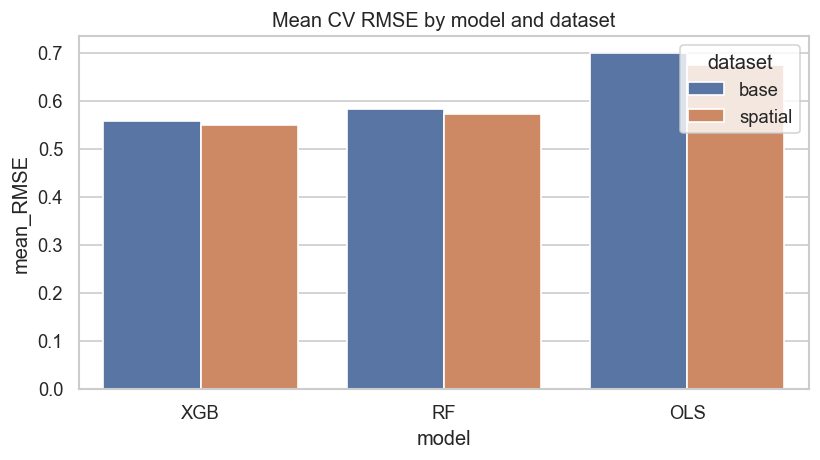

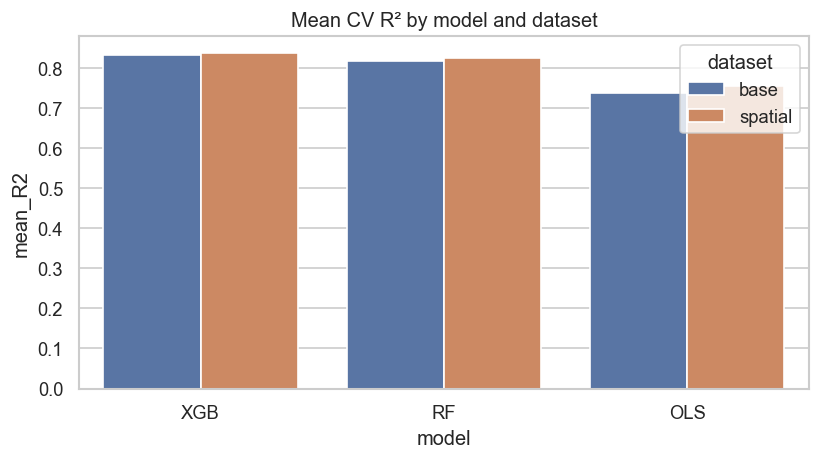

In [11]:
comparison = summary.rename(columns={
    "rmse_val_mean": "mean_RMSE",
    "rmse_val_std": "std_RMSE",
    "mae_val_mean": "mean_MAE",
    "mae_val_std": "std_MAE",
    "r2_val_mean": "mean_R2",
    "r2_val_std": "std_R2",
}).copy()

print("Model comparison:")
print(comparison.to_string(index=False))

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_RMSE", hue="dataset")
plt.title("Mean CV RMSE by model and dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "rmse_by_model_dataset.png")
plt.show()

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x="model", y="mean_R2", hue="dataset")
plt.title("Mean CV R² by model and dataset")
plt.tight_layout()
plt.savefig(OUT_DIR / "r2_by_model_dataset.png")
plt.show()


## 13. Overfitting / stability diagnostics


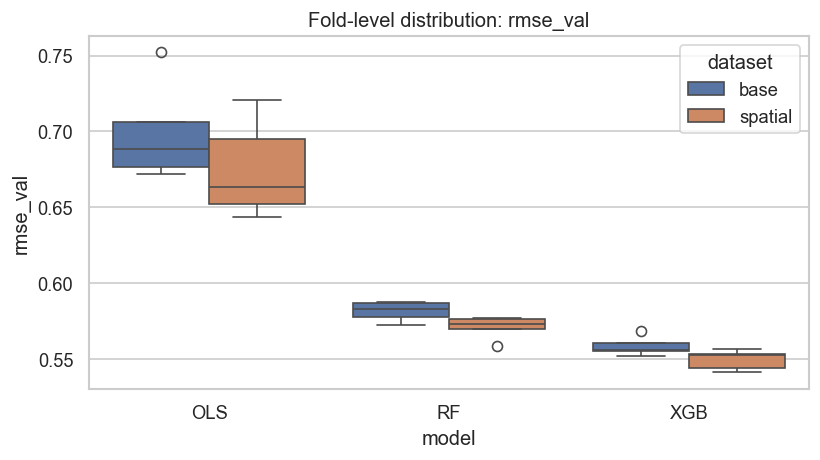

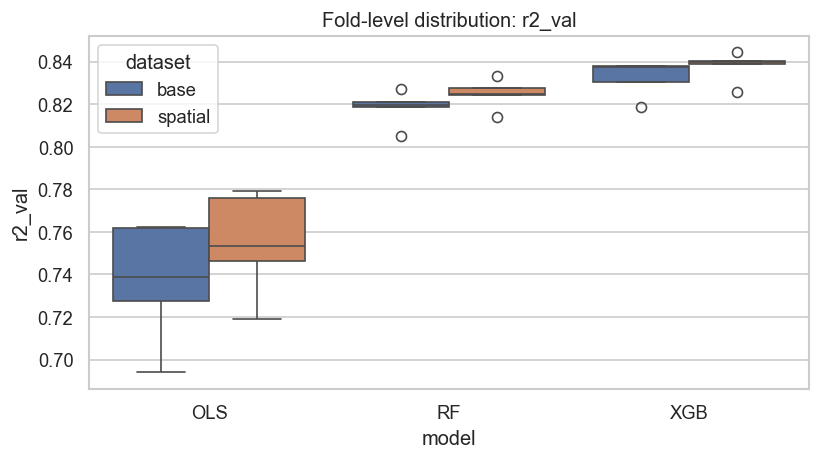


Train–validation gap (mean by model/dataset):
dataset model  rmse_gap  r2_gap
   base   OLS    0.0241  0.0224
   base    RF    0.3398  0.1508
   base   XGB    0.2906  0.1296
spatial   OLS    0.0252  0.0221
spatial    RF    0.3347  0.1456
spatial   XGB    0.2934  0.1276

Interpretation guide:
- Larger positive rmse_gap and r2_gap suggest overfitting.
- Large fold variance suggests instability.


In [12]:
def plot_fold_distributions(fold_df: pd.DataFrame, metric: str, filename: str):
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=fold_df, x="model", y=metric, hue="dataset")
    plt.title(f"Fold-level distribution: {metric}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / filename)
    plt.show()

plot_fold_distributions(fold_metrics, "rmse_val", "fold_rmse_val_box.png")
plot_fold_distributions(fold_metrics, "r2_val", "fold_r2_val_box.png")

fold_metrics["rmse_gap"] = fold_metrics["rmse_val"] - fold_metrics["rmse_train"]
fold_metrics["r2_gap"] = fold_metrics["r2_train"] - fold_metrics["r2_val"]

print("\nTrain–validation gap (mean by model/dataset):")
print(
    fold_metrics.groupby(["dataset", "model"])[["rmse_gap", "r2_gap"]]
    .mean()
    .round(4)
    .reset_index()
    .to_string(index=False)
)

print("\nInterpretation guide:")
print("- Larger positive rmse_gap and r2_gap suggest overfitting.")
print("- Large fold variance suggests instability.")


## 14. Error analysis and failure modes


Best model (base): XGB
Best model (spatial): XGB


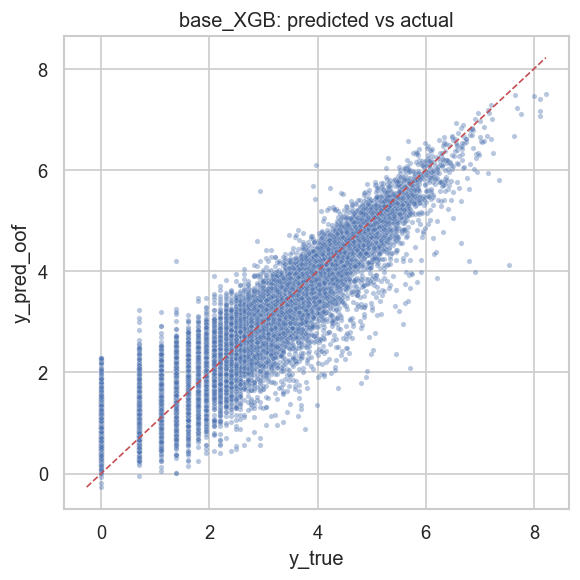

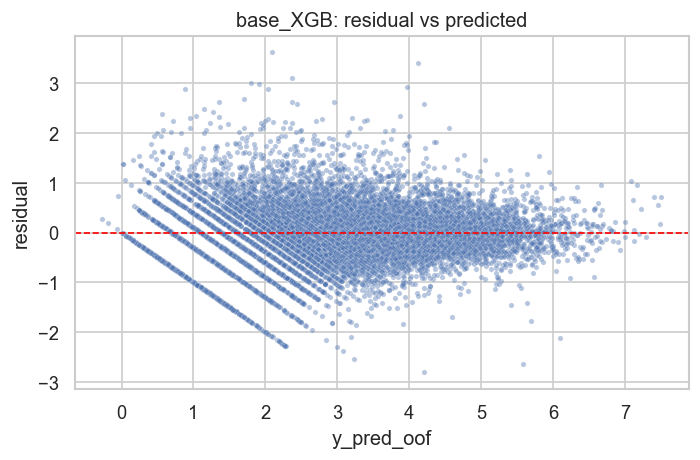

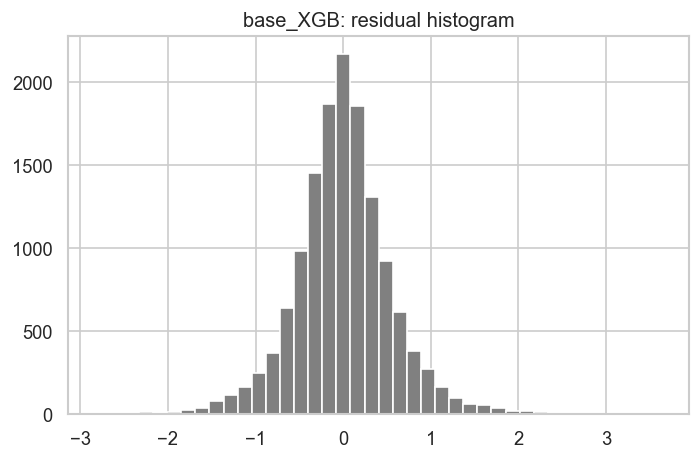


Worst absolute errors (top 20):
gwb_code_10             gm_naam  population  crime_count   y_true  y_pred_oof  abs_error
 BU19010405 Bodegraven-Reeuwijk       375.0        303.0 5.717028    2.092367   3.624661
 BU0363AD01           Amsterdam         5.0       1882.0 7.540622    4.124346   3.416276
 BU19040201      Stichtse Vecht       150.0        234.0 5.459586    2.363349   3.096236
 BU19040205      Stichtse Vecht        50.0        120.0 4.795791    1.793949   3.001841
 BU03562300          Nieuwegein        30.0        133.0 4.897840    1.915100   2.982740
 BU06060003            Schiedam       770.0        996.0 6.904751    3.974407   2.930343
 BU02286001                 Ede       215.0        136.0 4.919981    2.030347   2.889634
 BU09951098            Lelystad         5.0         42.0 3.761200    0.885554   2.875647
 BU02850101              Voorst      4230.0          3.0 1.386294    4.200421   2.814126
 BU09831405               Venlo       105.0         79.0 4.382027    1.696876

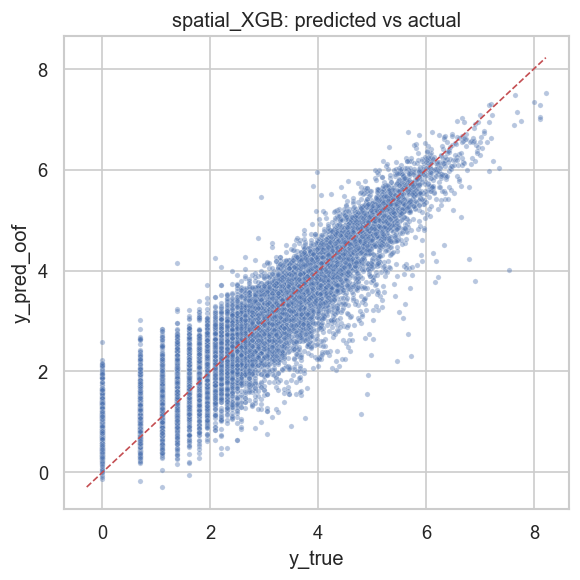

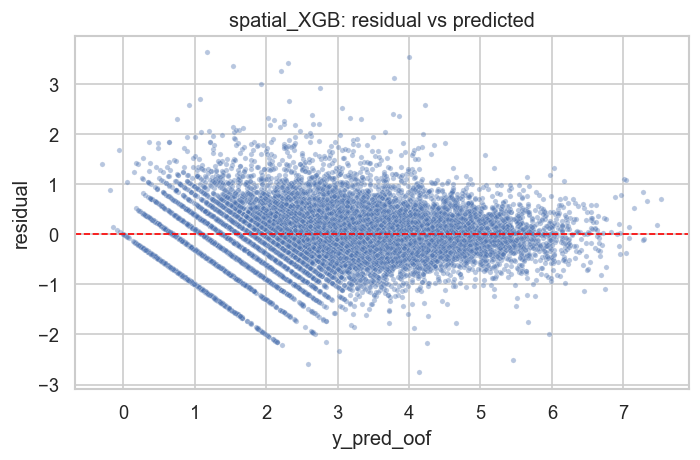

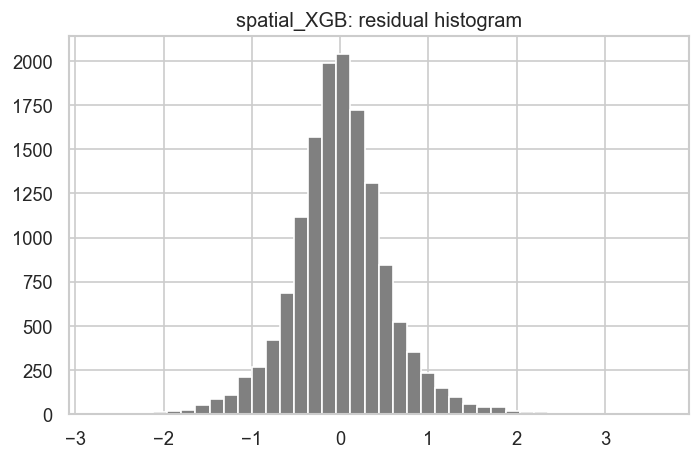


Worst absolute errors (top 20):
gwb_code_10             gm_naam  population  crime_count   y_true  y_pred_oof  abs_error
 BU19040205      Stichtse Vecht        50.0        120.0 4.795791    1.165010   3.630781
 BU0363AD01           Amsterdam         5.0       1882.0 7.540622    4.002563   3.538059
 BU19010405 Bodegraven-Reeuwijk       375.0        303.0 5.717028    2.309782   3.407246
 BU03562300          Nieuwegein        30.0        133.0 4.897840    1.542068   3.355772
 BU19040201      Stichtse Vecht       150.0        234.0 5.459586    2.202329   3.257257
 BU06060003            Schiedam       770.0        996.0 6.904751    3.783009   3.121742
 BU02286001                 Ede       215.0        136.0 4.919981    1.931584   2.988397
 BU07580506               Breda        55.0        290.0 5.673323    2.749865   2.923458
 BU02850101              Voorst      4230.0          3.0 1.386294    4.145193   2.758898
 BU09951098            Lelystad         5.0         42.0 3.761200    1.068660

In [13]:
def best_model_for_dataset(comp: pd.DataFrame, dataset: str) -> str:
    sub = comp[comp["dataset"] == dataset].sort_values("mean_RMSE")
    return str(sub.iloc[0]["model"])

best_base = best_model_for_dataset(comparison, "base")
best_spatial = best_model_for_dataset(comparison, "spatial")
print("Best model (base):", best_base)
print("Best model (spatial):", best_spatial)

def error_analysis(oof: pd.DataFrame, title_prefix: str):
    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=oof["y_true"], y=oof["y_pred_oof"], s=10, alpha=0.4)
    mn = min(oof["y_true"].min(), oof["y_pred_oof"].min())
    mx = max(oof["y_true"].max(), oof["y_pred_oof"].max())
    plt.plot([mn, mx], [mn, mx], "r--", linewidth=1)
    plt.title(f"{title_prefix}: predicted vs actual")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{title_prefix}_pred_vs_actual.png")
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=oof["y_pred_oof"], y=oof["residual"], s=10, alpha=0.4)
    plt.axhline(0, color="red", linestyle="--", linewidth=1)
    plt.title(f"{title_prefix}: residual vs predicted")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{title_prefix}_residual_vs_pred.png")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(oof["residual"], bins=40, color="gray", edgecolor="white")
    plt.title(f"{title_prefix}: residual histogram")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{title_prefix}_residual_hist.png")
    plt.show()

    worst = oof.sort_values("abs_error", ascending=False).head(20)
    ctx = [c for c in ["gwb_code_10", "gm_naam", "population", "crime_count"] if c in worst.columns]
    print("\nWorst absolute errors (top 20):")
    print(worst[ctx + ["y_true", "y_pred_oof", "abs_error"]].to_string(index=False))

    oof = oof.copy()
    oof["target_decile"] = pd.qcut(oof["y_true"], 10, labels=False, duplicates="drop")
    print("\nMean abs error by target decile:")
    print(oof.groupby("target_decile")["abs_error"].mean().reset_index().to_string(index=False))

    if "population" in oof.columns and pd.api.types.is_numeric_dtype(oof["population"]):
        try:
            oof["pop_decile"] = pd.qcut(oof["population"], 10, labels=False, duplicates="drop")
            print("\nMean abs error by population decile:")
            print(oof.groupby("pop_decile")["abs_error"].mean().reset_index().to_string(index=False))
        except Exception:
            pass

    if "gm_naam" in oof.columns:
        by_gm = (
            oof.groupby("gm_naam")["abs_error"].mean()
            .sort_values(ascending=False)
            .head(15)
            .reset_index()
        )
        print("\nHighest mean abs error municipalities (top 15):")
        print(by_gm.to_string(index=False))

base_best_oof = oof_predictions[(oof_predictions["dataset"] == "base") & (oof_predictions["model"] == best_base)].copy()
spatial_best_oof = oof_predictions[(oof_predictions["dataset"] == "spatial") & (oof_predictions["model"] == best_spatial)].copy()

error_analysis(base_best_oof, f"base_{best_base}")
error_analysis(spatial_best_oof, f"spatial_{best_spatial}")


## 15. Feature importance / interpretation (MVP)



Top 15 OLS coefficients (base):
 feature      coef
a_opp_ha 10.488959
a_lan_ha -9.969898
  a_bedv  1.965473
 a_ongeh -1.565945
 a_bst_b  1.292820
   a_man  1.277808
   a_pau -1.261094
a_neu_al  1.114070
 p_1gezw -1.090556
a_gehuwd -1.077701
a_wat_ha -0.996166
 p_mgezw -0.942887
a_bed_mn -0.763747
a_geb_ne -0.508623
    a_hh  0.482610


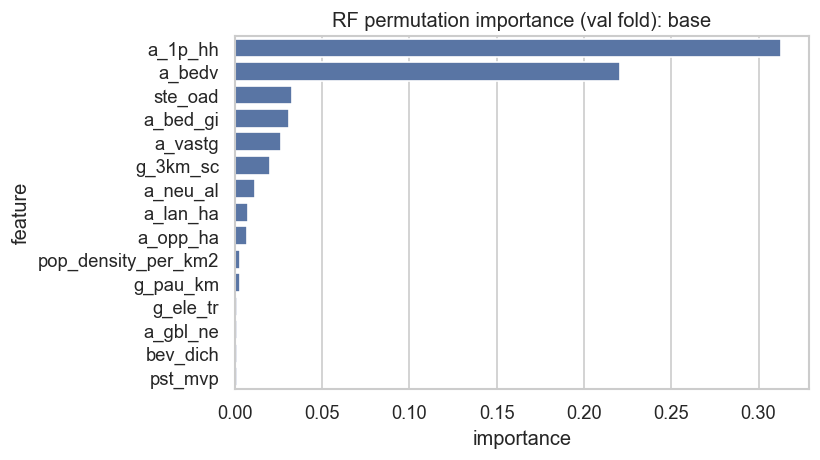

/Users/aukehilbrands/Documents/Studie/Thesis/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


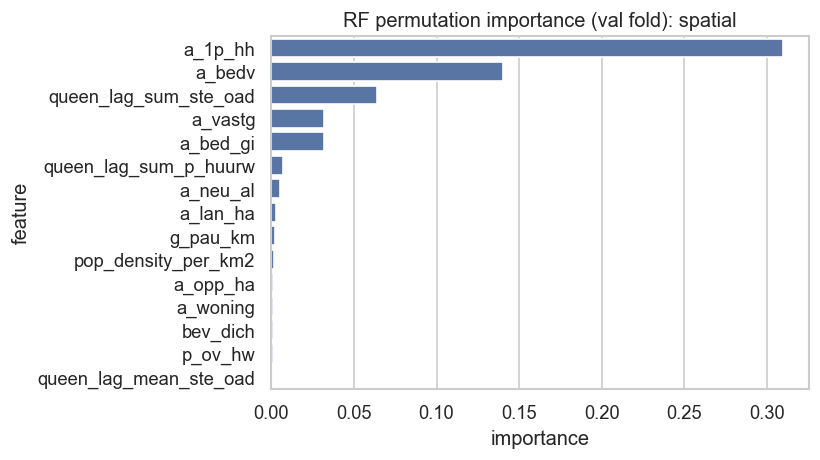

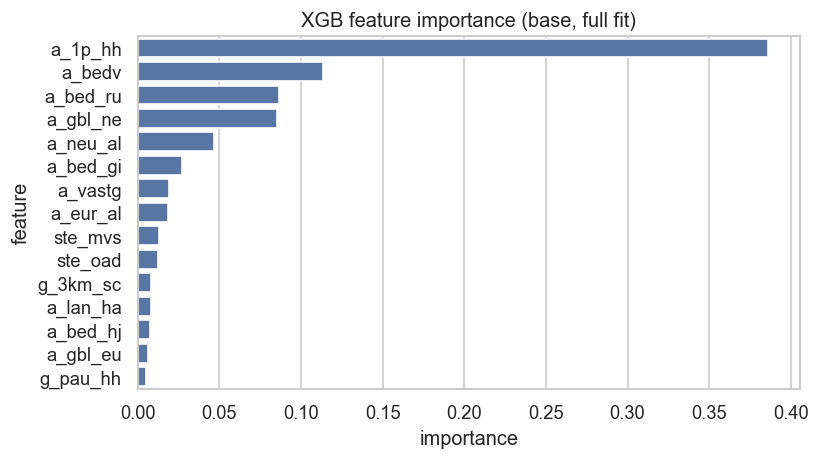

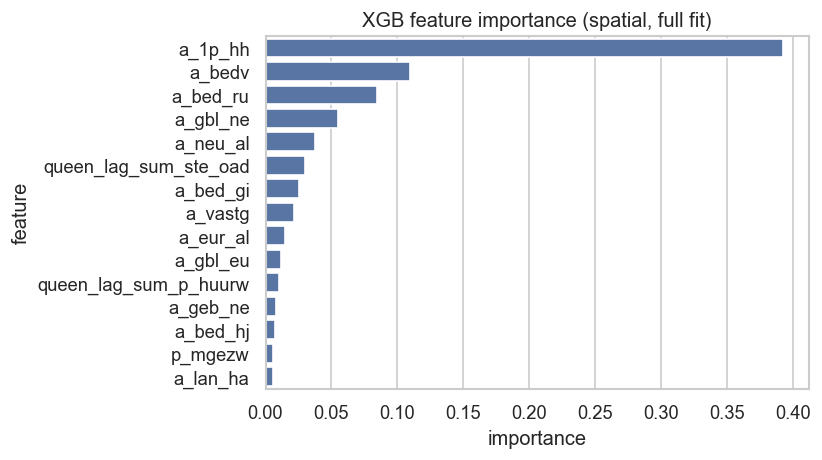


SHAP (optional later): create a separate notebook once model choice is stable.


In [14]:
def fit_full(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> Pipeline:
    m = Pipeline(steps=model.steps)
    return m.fit(X, y)

# OLS coefficients (scaled)
ols_full_base = fit_full(make_ols_pipeline(), X_base, y_base)
coef = ols_full_base.named_steps["model"].coef_
ols_coef_df = pd.DataFrame({"feature": X_base.columns, "coef": coef}).sort_values("coef", key=np.abs, ascending=False)
print("\nTop 15 OLS coefficients (base):")
print(ols_coef_df.head(15).to_string(index=False))
ols_coef_df.head(50).to_csv(OUT_DIR / "top_features_ols_base.csv", index=False)

# RF permutation importance on one validation fold (more defensible than full-data importance)

def rf_perm_imp_one_fold(X, y, cv, groups, tag: str):
    pipe = make_rf_pipeline()
    tr, va = next(iter(cv.split(X, y, groups)))
    pipe.fit(X.iloc[tr], y.iloc[tr])
    r = permutation_importance(pipe, X.iloc[va], y.iloc[va], n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
    imp = pd.DataFrame({"feature": X.columns, "importance": r.importances_mean}).sort_values("importance", ascending=False)
    imp.head(15).to_csv(OUT_DIR / f"top_features_rf_{tag}.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title(f"RF permutation importance (val fold): {tag}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"rf_top15_{tag}.png")
    plt.show()

rf_perm_imp_one_fold(X_base, y_base, cv_base, groups_base, "base")
rf_perm_imp_one_fold(X_spatial, y_spatial, cv_spatial, groups_spatial, "spatial")

if XGBOOST_AVAILABLE:
    xgb_full_base = fit_full(make_xgb_pipeline(), X_base, y_base)
    xgb_model = xgb_full_base.named_steps["model"]
    imp = pd.DataFrame({"feature": X_base.columns, "importance": xgb_model.feature_importances_}).sort_values("importance", ascending=False)
    imp.head(15).to_csv(OUT_DIR / "top_features_xgb_base.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (base, full fit)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "xgb_top15_base.png")
    plt.show()

    xgb_full_spatial = fit_full(make_xgb_pipeline(), X_spatial, y_spatial)
    xgb_model_s = xgb_full_spatial.named_steps["model"]
    imp_s = pd.DataFrame({"feature": X_spatial.columns, "importance": xgb_model_s.feature_importances_}).sort_values("importance", ascending=False)
    imp_s.head(15).to_csv(OUT_DIR / "top_features_xgb_spatial.csv", index=False)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=imp_s.head(15), x="importance", y="feature")
    plt.title("XGB feature importance (spatial, full fit)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "xgb_top15_spatial.png")
    plt.show()
else:
    print("XGBoost not available: skipping XGB feature importance")

print("\nSHAP (optional later): create a separate notebook once model choice is stable.")


## Initial comparison to literature

**Placeholder thesis note (no citations here yet):**

- Tree-based models often outperform linear baselines in crime prediction.
- Spatial/contextual features are often beneficial.
- Metrics are not directly comparable across studies due to different targets/units/validation.

TODO: add citations in the written thesis.


## 15. MVP conclusions and next iteration plan


In [15]:
print("=== MVP conclusions (auto prompts) ===")
best_overall = comparison.sort_values("mean_RMSE").iloc[0]
print("Best configuration by mean RMSE:")
print(best_overall.to_string())

print("\nNext iteration suggestions:")
print("- add modest tuning (not large searches)")
print("- add robustness checks (alternative CV, feature subsets)")
print("- inspect municipalities with high error")


=== MVP conclusions (auto prompts) ===
Best configuration by mean RMSE:
dataset       spatial
model             XGB
mean_RMSE    0.549445
std_RMSE     0.006753
mean_MAE     0.403967
std_MAE      0.006765
mean_R2      0.837797
std_R2       0.007069

Next iteration suggestions:
- add modest tuning (not large searches)
- add robustness checks (alternative CV, feature subsets)
- inspect municipalities with high error


## 16. Save outputs


In [16]:
fold_metrics_base = fold_metrics[fold_metrics["dataset"] == "base"].copy()
fold_metrics_spatial = fold_metrics[fold_metrics["dataset"] == "spatial"].copy()

fold_metrics_base.to_csv(OUT_DIR / "fold_metrics_base.csv", index=False)
fold_metrics_spatial.to_csv(OUT_DIR / "fold_metrics_spatial.csv", index=False)
comparison.to_csv(OUT_DIR / "model_comparison_summary.csv", index=False)

oof_base = oof_predictions[oof_predictions["dataset"] == "base"].copy()
oof_spatial = oof_predictions[oof_predictions["dataset"] == "spatial"].copy()

oof_base.to_csv(OUT_DIR / "oof_predictions_base.csv", index=False)
oof_spatial.to_csv(OUT_DIR / "oof_predictions_spatial.csv", index=False)

print("Saved outputs to:", OUT_DIR)


Saved outputs to: outputs/modeling_mvp


## Methods paragraph draft

This study evaluates a minimum viable set of predictive models for neighborhood-level crime intensity across Dutch neighborhoods using two feature sets: a non-spatial baseline dataset and an augmented dataset with exogenous spatial spillover features based on queen contiguity. The outcome variable is a log-transformed crime count produced in preprocessing (`log_crime_count = log1p(crime_count)`). Three regression models are compared: ordinary least squares linear regression, a random forest regressor, and an XGBoost regressor. Model evaluation uses five-fold cross-validation, preferring grouped cross-validation by municipality when an appropriate grouping variable is available, and reports RMSE, MAE, and R². All preprocessing steps that can introduce leakage (median imputation and scaling for linear regression) are implemented inside scikit-learn pipelines and fitted within each training fold. Out-of-fold predictions are retained for diagnostic plots and error analysis.
